# FIN5016 Assignment 1B
## A Machine Learning Model to Classify Credit Risk for Loan Applicants

### Objective
The aim of this project is to develop a machine learning model to classify whether a loan applicant is likely to default or repay a loan using historical credit data.

### Importing Required Libraries
All the necessary libraries were imported to support data analysis, visualization, and model development.

Pandas and NumPy were used for data manipulation and numerical operations, while Matplotlib was used for creating visualizations.

Scikit-learn libraries were imported for building and evaluating machine learning models, including functions for data splitting, model training, hyperparameter tuning, and performance evaluation.

Warnings were also suppressed to keep the output clean and easier to read.

In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


### Loading the Dataset
The dataset was loaded into the notebook using the pandas library. The `read_csv()` function was used to read the CSV file and store it in a DataFrame. This allows the data to be easily accessed, analysed, and processed for further steps in the project.

In [ ]:
df = pd.read_csv('UCI_Credit_Card[1].csv')

### Loading the Dataset
The dataset was loaded into the Python environment using the `pandas` library with the `read_csv()` function. The data was stored in a DataFrame named `df`. The `head()` function was used to display the first five rows of the dataset to verify that it was loaded correctly and to preview the structure of the data.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/UCI_Credit_Card[1].csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Dataset Size
The `shape` function was used to determine the dimensions of the dataset. It returns the number of rows and columns in the DataFrame, where rows represent the number of observations (customers) and columns represent the number of features (variables).

In [ ]:
df.shape

(30000, 25)

### Dataset Structure
The `info()` function was used to display the structure of the dataset. It provides information about the column names, data types, and the number of non-null values in each column. This helps identify whether there are any missing values and understand the type of data present in each feature.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

### Summary Statistics
The `describe()` function was used to generate summary statistics for the numerical features in the dataset. It provides key measures such as mean, standard deviation, minimum, maximum, and quartiles. This helps in understanding the distribution of the data and identifying any potential outliers.

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Checking Duplicate Values
The `duplicated().sum()` function was used to identify duplicate rows in the dataset. It counts the number of repeated records. This step ensures that the dataset does not contain redundant data that could affect the accuracy of the model.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Handling Outliers
Outliers are extreme values that differ significantly from other observations in the dataset and can negatively affect model performance. To address this, the Interquartile Range (IQR) method was used.

For each numerical feature, the first quartile (Q1) and third quartile (Q3) were calculated, and the IQR was obtained as the difference between Q3 and Q1. Any values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered outliers.

These extreme values were capped within the acceptable range using the `clip()` function, which helps in reducing their impact while preserving the overall dataset.

In [ ]:
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

    return df

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('default.payment.next.month')

df = cap_outliers(df, num_cols)

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,166967.489333,1.603733,1.832833,1.551867,35.449467,-0.094033,-0.232367,-0.259683,-0.303967,...,36551.073642,33754.151258,32595.088604,3496.730800,3422.306967,3035.817900,2718.296075,2731.547167,2714.437875,0.221200
std,8660.398374,128013.394323,0.489129,0.724378,0.521970,9.106024,0.951983,0.991794,0.995493,0.969589,...,42751.481350,39896.030557,39367.735129,3492.742781,3532.819886,3355.632738,3073.301491,3094.091228,3131.180741,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-75942.125000,-70878.250000,-70657.375000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,833.000000,390.000000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2009.000000,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5000.000000,4505.000000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,525000.000000,2.000000,3.500000,3.000000,60.500000,1.500000,1.500000,1.500000,1.500000,...,132774.875000,122831.750000,121111.625000,11015.000000,11250.500000,10677.500000,9589.125000,9700.000000,9823.375000,1.000000


### Encoding Categorical Variables
Categorical variables such as SEX, EDUCATION, and MARRIAGE were converted into numerical format using one-hot encoding with the `get_dummies()` function. This process creates new binary columns for each category, allowing machine learning models to interpret the data effectively.

The parameter `drop_first=True` was used to avoid multicollinearity by removing one category from each variable.

Additionally, the resulting boolean values were converted into integers (0 and 1) using `astype(int)` to ensure compatibility with machine learning algorithms. The `head()` function was used to display the first few rows of the transformed dataset.

In [ ]:
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)
df = df.astype(int)
df.head()

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT6,default.payment.next.month,SEX_2,EDUCATION_1.0,EDUCATION_2.0,EDUCATION_3.0,EDUCATION_3.5,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,20000,24,1,1,-1,-1,-2,-2,3913,...,0,1,1,0,1,0,0,1,0,0
1,2,120000,26,-1,1,0,0,0,1,2682,...,2000,1,1,0,1,0,0,0,1,0
2,3,90000,34,0,0,0,0,0,0,29239,...,5000,0,1,0,1,0,0,0,1,0
3,4,50000,37,0,0,0,0,0,0,46990,...,1000,0,1,0,1,0,0,1,0,0
4,5,50000,57,-1,0,-1,0,0,0,8617,...,679,0,0,0,1,0,0,1,0,0


### Defining Features and Target Variable
The dataset was divided into input features (X) and the target variable (y). The target variable represents whether a customer defaults on their payment, while the remaining variables are used as predictors.

### Train-Test Split
The `train_test_split()` function was used to divide the dataset into training and testing sets. 80% of the data (24,000 observations) was used for training, and 20% (6,000 observations) was used for testing. This ensures that the model is trained on a large portion of the data while still being evaluated on unseen data. The parameter `random_state=42` ensures reproducibility of the results.

In [ ]:
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(24000, 29)
(6000, 29)


### Distribution of Target Variable
The distribution of the target variable was visualised to understand the proportion of customers who defaulted and those who did not. The results indicate that there are more non-default cases than default cases, suggesting a class imbalance in the dataset.

In [ ]:
df['default.payment.next.month'].value_counts()

,count
default.payment.next.month,
0,23364
1,6636


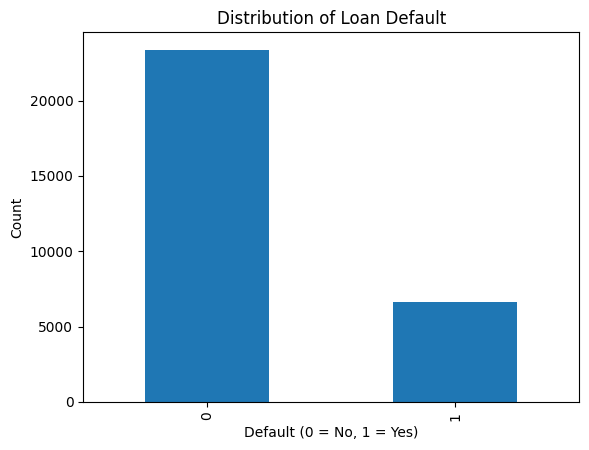

In [ ]:
import matplotlib.pyplot as plt

df['default.payment.next.month'].value_counts().plot(kind='bar')
plt.title("Distribution of Loan Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### Distribution of Numerical Features
Histograms were used to visualise the distribution of numerical features such as age and credit limit. The age distribution shows that most customers fall within a specific age range, while the credit limit distribution appears skewed, indicating that most customers have lower credit limits compared to a few with very high limits.

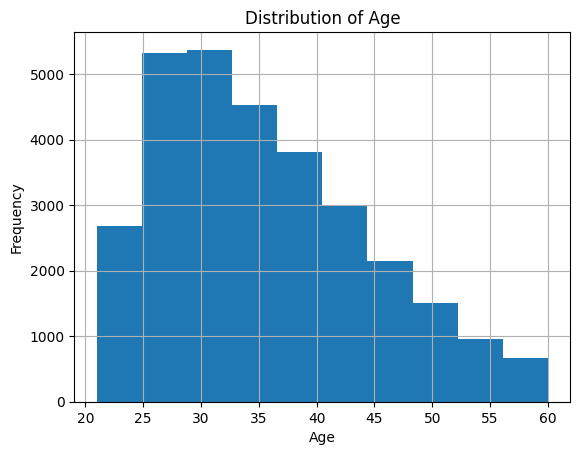

In [ ]:
df['AGE'].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

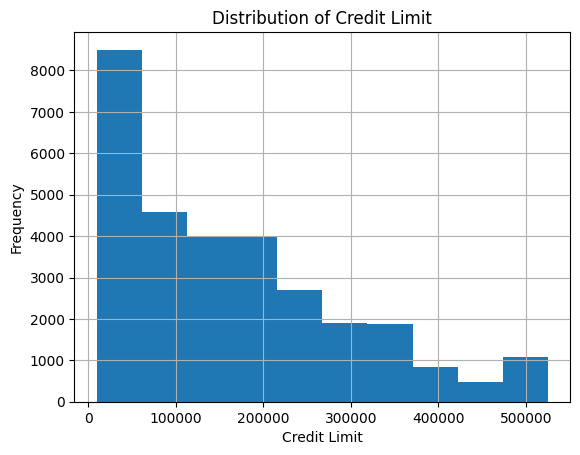

In [ ]:
df['LIMIT_BAL'].hist()
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

In [ ]:
corr = df.corr()
corr

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT6,default.payment.next.month,SEX_2,EDUCATION_1.0,EDUCATION_2.0,EDUCATION_3.0,EDUCATION_3.5,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
ID,1.000000,0.026428,0.019198,-0.033536,-0.009774,-0.013957,-0.008047,-0.020408,-0.013148,0.017410,...,0.029366,-0.013952,0.018497,-0.025858,0.002569,0.017475,0.036802,0.026687,-0.023794,-0.015255
LIMIT_BAL,0.026428,1.000000,0.144995,-0.278543,-0.310209,-0.296931,-0.272953,-0.249988,-0.232582,0.198284,...,0.371923,-0.154380,0.025538,0.260714,-0.148458,-0.140990,0.012292,0.104573,-0.091800,-0.056141
AGE,0.019198,0.144995,1.000000,-0.051760,-0.065409,-0.065823,-0.063933,-0.066265,-0.057693,0.037993,...,0.034947,0.013649,-0.090768,-0.101109,-0.076995,0.231217,0.007897,0.452004,-0.469406,0.083834
PAY_0,-0.033536,-0.278543,-0.051760,1.000000,0.625206,0.557371,0.524713,0.497181,0.472747,0.262305,...,-0.073077,0.249590,-0.056009,-0.146072,0.103780,0.056672,-0.022697,-0.024750,0.020870,0.021894
PAY_2,-0.009774,-0.310209,-0.065409,0.625206,1.000000,0.818401,0.730501,0.688620,0.645918,0.389087,...,0.015816,0.198735,-0.072697,-0.188592,0.138240,0.065982,-0.023841,-0.035631,0.032550,0.016593
PAY_3,-0.013957,-0.296931,-0.065823,0.557371,0.818401,1.000000,0.821493,0.738488,0.685910,0.364146,...,0.030250,0.178050,-0.067929,-0.181442,0.132454,0.064654,-0.024283,-0.040226,0.036478,0.020019
PAY_4,-0.008047,-0.272953,-0.063933,0.524713,0.730501,0.821493,1.000000,0.842988,0.748947,0.357719,...,0.061680,0.157697,-0.059187,-0.170575,0.126093,0.058251,-0.021826,-0.042025,0.038435,0.020470
PAY_5,-0.020408,-0.249988,-0.066265,0.497181,0.688620,0.738488,0.842988,1.000000,0.839063,0.350581,...,0.084058,0.144087,-0.052231,-0.154133,0.115936,0.049933,-0.018904,-0.045317,0.042464,0.016376
PAY_6,-0.013148,-0.232582,-0.057693,0.472747,0.645918,0.685910,0.748947,0.839063,1.000000,0.348053,...,0.100104,0.130339,-0.040961,-0.140615,0.110833,0.042539,-0.027482,-0.040698,0.037168,0.019841
BILL_AMT1,0.017410,0.198284,0.037993,0.262305,0.389087,0.364146,0.357719,0.350581,0.348053,1.000000,...,0.379735,-0.029033,-0.030498,-0.051004,0.048586,-0.012855,0.042466,0.021377,-0.017432,-0.010748


### Correlation Analysis
A correlation matrix was created to examine the relationships between different features in the dataset. The heatmap shows that repayment status variables (such as PAY_0, PAY_2, etc.) have strong correlations with each other and are more closely related to the likelihood of default.

Billing amount variables also show strong positive correlations, indicating that customers with high bill amounts tend to maintain similar levels across different months.

In contrast, demographic variables such as age, sex, and education show weak correlations with the target variable, suggesting that they have less influence on predicting loan default. Overall, payment history appears to be the most significant factor in determining credit risk.

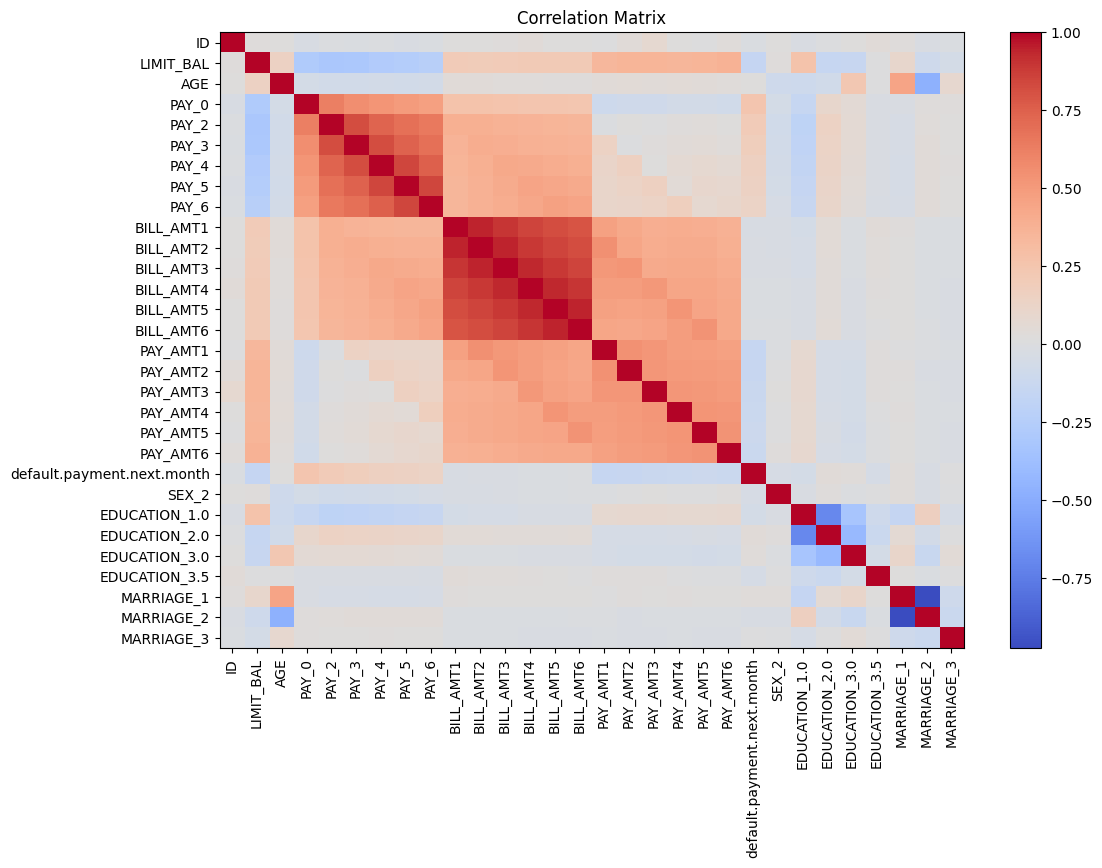

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

### Patterns Related to Loan Default
To identify patterns related to loan default, key variables were analysed by comparing their average values across default and non-default groups using groupby analysis.

The results show that age does not significantly differ between defaulters and non-defaulters, indicating that age is not a strong predictor of default.

However, customers who default tend to have lower credit limits compared to those who do not default, suggesting that lower financial capacity may increase default risk.

The most significant factor is repayment behaviour, particularly the PAY_0 variable. Defaulters have higher values, indicating delayed payments, while non-defaulters show lower or negative values, indicating timely payments. This suggests that payment history is the strongest predictor of loan default.

In [ ]:
df.groupby('default.payment.next.month')['AGE'].mean()

,AGE
default.payment.next.month,
0,35.378788
1,35.677818


In [ ]:
df.groupby('default.payment.next.month')['LIMIT_BAL'].mean()

,LIMIT_BAL
default.payment.next.month,
0,177499.657593
1,129885.877034


In [ ]:
df.groupby('default.payment.next.month')['PAY_0'].mean()

,PAY_0
default.payment.next.month,
0,-0.262412
1,0.262960


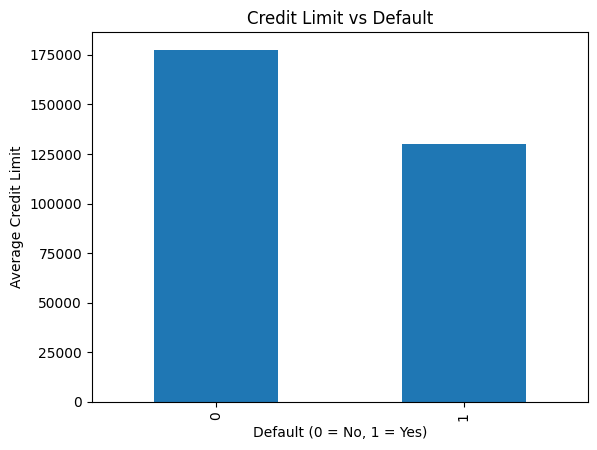

In [ ]:
df.groupby('default.payment.next.month')['LIMIT_BAL'].mean().plot(kind='bar')
plt.title("Credit Limit vs Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Average Credit Limit")
plt.show()

### Feature Engineering
New features were created to improve model performance. These include total bill amount, total payment amount, payment ratio, average payment delay and credit utilisation. These variables provide more meaningful information about customer repayment behaviour and financial pressure, which may help the model predict default more accurately.

In [ ]:
df['TOTAL_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                       'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

In [ ]:
df['TOTAL_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                      'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

In [ ]:
df['PAY_RATIO'] = df['TOTAL_PAY'] / (df['TOTAL_BILL'] + 1)

In [ ]:
df['AVG_PAY_DELAY'] = df[['PAY_0','PAY_2','PAY_3',
                          'PAY_4','PAY_5','PAY_6']].mean(axis=1)

In [ ]:
df['UTILIZATION'] = df['TOTAL_BILL'] / (df['LIMIT_BAL'] + 1)

In [ ]:
df[['TOTAL_BILL', 'TOTAL_PAY', 'PAY_RATIO', 'AVG_PAY_DELAY', 'UTILIZATION']].head()

,TOTAL_BILL,TOTAL_PAY,PAY_RATIO,AVG_PAY_DELAY,UTILIZATION
0,7704,689,0.089422,-0.666667,0.385181
1,17077,5000,0.292774,0.166667,0.142307
2,101653,11018,0.108387,0.000000,1.129465
3,231334,8388,0.036259,0.000000,4.626587
4,109339,33618,0.307463,-0.333333,2.186736


### Updating Train-Test Split After Feature Engineering
After creating new features, the dataset was redefined and split again into training and testing sets. This ensures that the newly engineered features are included in the model training and evaluation process.

In [ ]:
# Re-define X and y after feature engineering
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

# Split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(24000, 34)
(6000, 34)


### Feature Selection
Feature selection was performed using correlation analysis to identify the most relevant variables for predicting loan default. The results showed that repayment status variables such as PAY_0, PAY_2, PAY_3, and AVG_PAY_DELAY have the strongest positive correlation with default, indicating that payment delay is the most important factor.

Additionally, variables such as credit utilisation and total payment were also found to be relevant. Negative correlations for features such as LIMIT_BAL and TOTAL_PAY suggest that higher credit limits and higher repayments reduce the likelihood of default.

Less relevant features such as age, education, and marital status were excluded as they showed weak correlations with the target variable. This helps reduce noise and improves model performance.

In [ ]:
corr_target = df.corr()['default.payment.next.month'].sort_values(ascending=False)
corr_target

,default.payment.next.month
default.payment.next.month,1.000000
PAY_0,0.249590
AVG_PAY_DELAY,0.205795
PAY_2,0.198735
PAY_3,0.178050
PAY_4,0.157697
PAY_5,0.144087
PAY_6,0.130339
UTILIZATION,0.120391
EDUCATION_2.0,0.036467


In [ ]:
selected_features = [
    'LIMIT_BAL',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'AVG_PAY_DELAY',
    'UTILIZATION',
    'TOTAL_PAY'
]

In [ ]:
X = df[selected_features]
y = df['default.payment.next.month']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Prediction
After training the models, predictions were made on the testing dataset using the `predict()` function. This step allows the model’s performance to be evaluated by comparing predicted values with actual outcomes.

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

### Cross-Validation
Cross-validation was performed using a 5-fold approach to evaluate the performance of the Logistic Regression model. The dataset was split into five subsets, and the model was trained and validated multiple times.

The average cross-validation accuracy was approximately 79%, indicating that the model performs consistently across different data splits and provides reliable predictions.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores_log = cross_val_score(log_model, X_train, y_train, cv=5)

print("Logistic Regression CV Accuracy:", cv_scores_log.mean())

Logistic Regression CV Accuracy: 0.7904166666666667


### Hyperparameter Tuning using GridSearchCV
Hyperparameter tuning was performed for the Random Forest model using GridSearchCV. This method systematically tests different combinations of model parameters to identify the optimal configuration.

The parameters tuned included the number of trees (`n_estimators`) and the maximum depth of the trees (`max_depth`). A 3-fold cross-validation approach was used to evaluate each combination.

The best parameters obtained were:
- Number of trees (`n_estimators`) = 100
- Maximum depth (`max_depth`) = 5

These optimized parameters help improve the model’s performance and ensure better generalization on unseen data.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       cv=3)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10], 'n_estimators': [50, 100]})

In [ ]:
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


### Model Training
The Logistic Regression and Random Forest models were trained using the training dataset. The Random Forest model was trained using the optimized hyperparameters obtained from GridSearchCV.

This step allows the models to learn patterns from historical data and prepares them for predicting loan default on unseen data.

In [ ]:
best_rf = grid_rf.best_estimator_

In [ ]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

### Model Evaluation
The performance of the Logistic Regression and Random Forest models was evaluated using accuracy and confusion matrix.

The Logistic Regression model achieved an accuracy of approximately 79%, while the Random Forest model achieved a higher accuracy of approximately 81%.

The confusion matrix shows that the Random Forest model is better at identifying default cases compared to Logistic Regression. Logistic Regression incorrectly classified a large number of defaulters, while Random Forest was able to correctly identify more default cases.

Overall, the Random Forest model performed better in terms of both accuracy and its ability to detect loan defaults, making it a more suitable model for this classification problem.

In [ ]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7905
Random Forest Accuracy: 0.8141666666666667


In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7905
Random Forest Accuracy: 0.8141666666666667


In [ ]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
 [[4605   82]
 [1175  138]]
Random Forest Confusion Matrix:
 [[4413  274]
 [ 841  472]]


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_log))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88      4687
           1       0.63      0.11      0.18      1313

    accuracy                           0.79      6000
   macro avg       0.71      0.54      0.53      6000
weighted avg       0.76      0.79      0.73      6000

Random Forest:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



### Confusion Matrix Analysis
Confusion matrices were created to evaluate the performance of both Logistic Regression and Random Forest models.

The Logistic Regression model correctly classified most non-default cases but performed poorly in identifying default cases, as it misclassified a large number of defaulters.

In contrast, the Random Forest model showed improved performance by correctly identifying a higher number of default cases, while still maintaining good accuracy for non-default cases.

Overall, the Random Forest model demonstrated better balance and effectiveness in predicting loan default, making it more suitable for this classification problem.

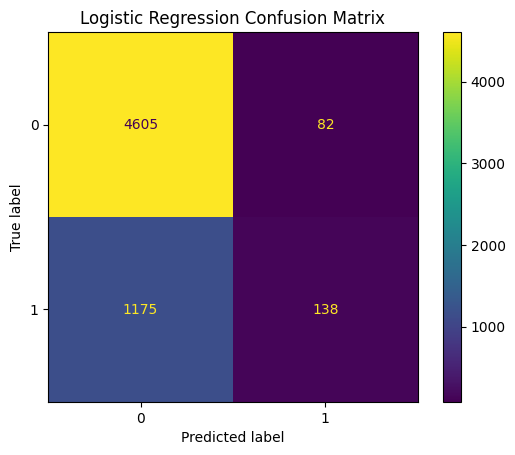

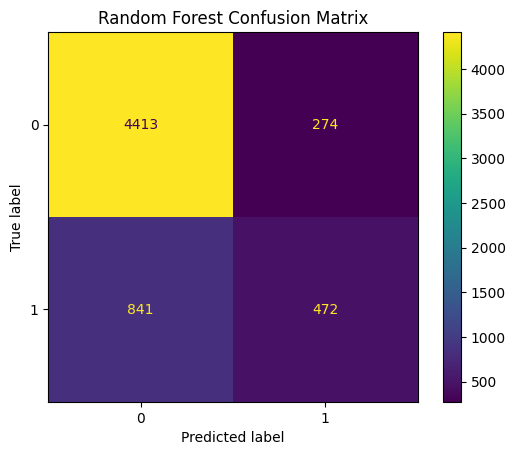

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

### ROC Curve Analysis
The ROC (Receiver Operating Characteristic) curve was used to evaluate the classification performance of the models. It plots the true positive rate against the false positive rate at different threshold levels.

The Area Under the Curve (AUC) provides a single measure of overall model performance. A higher AUC value indicates better classification ability.

The Random Forest model achieved a higher AUC compared to Logistic Regression, indicating that it is more effective in distinguishing between default and non-default cases.

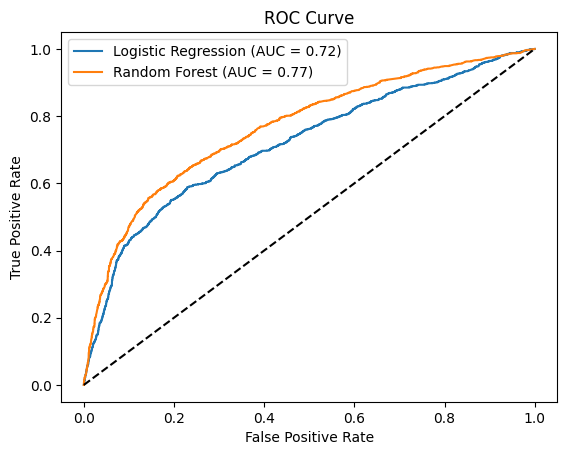

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure()

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Model Comparison

To compare the performance of the two models, Logistic Regression and Random Forest, several evaluation metrics were used, including accuracy, confusion matrix, and ROC curve.

The results show that the Random Forest model performed better overall, achieving a higher accuracy (around 81%) compared to Logistic Regression (around 79%). While Logistic Regression was good at predicting customers who do not default, it struggled to correctly identify customers who are likely to default.

On the other hand, the Random Forest model was more effective in detecting default cases, which is very important in a credit risk scenario. Even though it produced slightly more false positives, it was able to capture more high-risk customers.

The ROC curve also supported this result, as the Random Forest model had a higher AUC value, indicating better ability to distinguish between default and non-default cases.

Overall, Random Forest is the better model for this problem because it provides more accurate predictions and is more reliable in identifying customers who are likely to default.

### Important Features Influencing Credit Risk

The most important factors influencing credit risk are mainly related to a customer’s repayment behaviour. Variables such as payment status (PAY_0, PAY_2, PAY_3, etc.) and the average payment delay were found to have the strongest impact on predicting loan default. Customers who frequently delay their payments are much more likely to default, making these variables the most critical indicators.

Credit utilisation is another key factor. Customers who use a large portion of their available credit are more likely to experience financial stress, which increases the likelihood of default.

Payment-related features such as total payment and payment ratio also play an important role. Customers who repay a smaller portion of their outstanding balance are generally at higher risk.

In addition, the credit limit was found to be negatively related to default, meaning that customers with higher credit limits tend to be more financially stable and less likely to default.

On the other hand, demographic factors such as age, education, and marital status showed relatively weak relationships with default, indicating that they are less important in predicting credit risk.

Overall, repayment behaviour and financial patterns are the most significant factors influencing credit risk.

### Application of the Model in Loan Approval Process

The developed machine learning model can be used as a decision-support tool in the loan approval process by predicting whether a customer is likely to default or repay their loan.

Firstly, the model can help classify applicants into high-risk and low-risk categories. Customers predicted as high risk (likely to default) can be rejected or subjected to stricter loan conditions, while low-risk customers can be approved more easily.

Secondly, the model can assist banks in setting appropriate credit limits and interest rates based on the predicted risk level. For example, higher-risk customers may be offered lower credit limits or higher interest rates to compensate for the risk.

The model can also be used as an early warning system by identifying existing customers who may become risky in the future, allowing banks to take preventive actions such as sending reminders or restructuring payments.

In addition, using this model can improve efficiency by automating the initial screening process, reducing manual effort and speeding up decision-making.

Overall, the model helps financial institutions make more informed, consistent, and data-driven decisions, ultimately reducing default risk and improving profitability.

### Limitations and Areas for Improvement

Although the developed models perform reasonably well, there are several limitations that should be considered.

Firstly, the dataset is imbalanced, with significantly more non-default cases than default cases. This can affect the model’s ability to correctly identify defaulters, as it may become biased towards predicting non-default outcomes.

Secondly, the models rely only on the available features in the dataset. Important external factors such as income level, employment status, or macroeconomic conditions are not included, which may limit the model’s ability to fully capture credit risk.

Another limitation is that Logistic Regression assumes a linear relationship between features and the target variable, which may not always hold true in real-world financial data. While Random Forest addresses this to some extent, further improvements could be made using more advanced models.

In addition, feature engineering was based on simple transformations. More sophisticated techniques could be applied to extract deeper insights from the data.

For future improvement, techniques such as handling class imbalance (e.g., oversampling or SMOTE), testing additional machine learning models (such as Gradient Boosting or XGBoost), and performing more advanced hyperparameter tuning could be explored.

Overall, while the current model provides useful insights, there is potential to enhance its performance and robustness through further refinement.